# Model Training
---
In this notebook we train five classification models on the preprocessed student mental health dataset.
We evaluate each model using classification reports, confusion matrices, and 5-fold cross-validation.
All models are trained on a 50k sample for speed. The best model is then retrained on the full dataset and saved.

**Models compared:**
- Logistic Regression
- Random Forest
- XGBoost
- K-Nearest Neighbors (KNN) with best-k search
- Support Vector Machine (SVM)

## Imports

In [41]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## Load Preprocessed Data
We load the arrays saved by notebook 02. All scaling and encoding has already been applied.

In [42]:
X_train_full = np.load('../models/X_train.npy')
X_test        = np.load('../models/X_test.npy')
y_train_full  = np.load('../models/y_train.npy')
y_test        = np.load('../models/y_test.npy')

with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

print("Full X_train shape:", X_train_full.shape)
print("X_test shape:      ", X_test.shape)
print("Features:", feature_names)

Full X_train shape: (800000, 12)
X_test shape:       (200000, 12)
Features: ['age', 'gender', 'study_hours_per_day', 'exam_pressure', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'financial_stress', 'family_expectation']


## Create 50k Training Sample
All models are trained on a stratified 50,000-row sample during the comparison phase.
This keeps training times manageable. The winning model will be retrained on the full dataset afterwards.

In [43]:
X_train, y_train = resample(
    X_train_full, y_train_full,
    n_samples=50000,
    random_state=42,
    stratify=y_train_full
)

print("Sample X_train shape:", X_train.shape)
print("Class distribution in sample:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    label = {0: 'Low', 1: 'Medium', 2: 'High'}[u]
    print(f"  {label}: {c} ({c/len(y_train)*100:.1f}%)")

Sample X_train shape: (50000, 12)
Class distribution in sample:
  Low: 38332 (76.7%)
  Medium: 10914 (21.8%)
  High: 754 (1.5%)


## Helper Functions
Two reusable functions — one for printing metrics, one for plotting confusion matrices.

In [44]:
TARGET_NAMES = ['Low', 'Medium', 'High']

def evaluate_model(name, y_true, y_pred):
    """Print classification report and return accuracy and weighted F1."""
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES))
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    print(f"Accuracy:        {acc:.4f}")
    print(f"F1 (weighted):   {f1:.4f}")
    return acc, f1

def plot_confusion_matrix(name, y_true, y_pred):
    """Plot a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12, pad=12)
    plt.tight_layout()
    plt.show()

In [45]:

results = []

---
## 1. Logistic Regression
A linear model that serves as our baseline. Fast to train and easy to interpret.


  Logistic Regression
              precision    recall  f1-score   support

         Low       0.91      0.94      0.92    153329
      Medium       0.72      0.65      0.68     43655
        High       0.67      0.32      0.44      3016

    accuracy                           0.87    200000
   macro avg       0.76      0.64      0.68    200000
weighted avg       0.86      0.87      0.86    200000

Accuracy:        0.8669
F1 (weighted):   0.8624


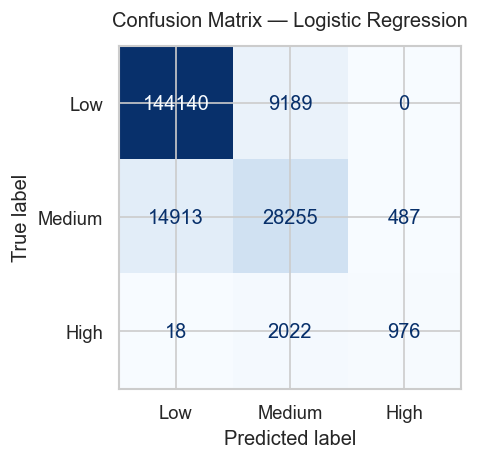

In [46]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_acc, lr_f1 = evaluate_model('Logistic Regression', y_test, lr_preds)
plot_confusion_matrix('Logistic Regression', y_test, lr_preds)

In [47]:
lr_cv = cross_val_score(lr, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)

print("Logistic Regression — 5-Fold Cross-Validation")
print(f"  Fold scores: {lr_cv.round(4)}")
print(f"  Mean F1:     {lr_cv.mean():.4f}")
print(f"  Std:         {lr_cv.std():.4f}")

results.append({'Model': 'Logistic Regression', 'Accuracy': lr_acc,
                'F1 (test)': lr_f1, 'CV F1 Mean': lr_cv.mean(), 'CV F1 Std': lr_cv.std()})

Logistic Regression — 5-Fold Cross-Validation
  Fold scores: [0.8624 0.8652 0.8645 0.8646 0.8653]
  Mean F1:     0.8644
  Std:         0.0011


---
## 2. Random Forest
An ensemble of decision trees. Handles non-linear relationships well and provides feature importance.


  Random Forest
              precision    recall  f1-score   support

         Low       0.90      0.94      0.92    153329
      Medium       0.71      0.63      0.67     43655
        High       0.79      0.17      0.28      3016

    accuracy                           0.86    200000
   macro avg       0.80      0.58      0.62    200000
weighted avg       0.86      0.86      0.86    200000

Accuracy:        0.8631
F1 (weighted):   0.8561


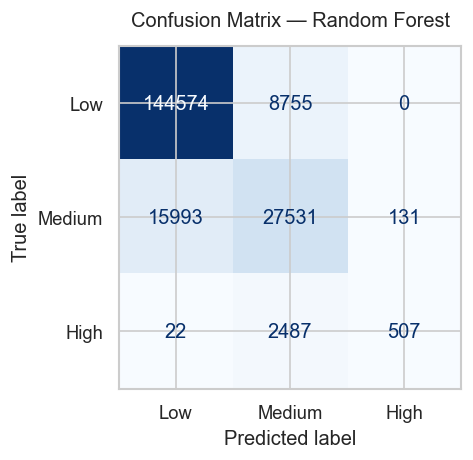

In [48]:
rf = RandomForestClassifier(n_estimators=100,max_depth=12,min_samples_leaf=20,min_samples_split=40,random_state=42,n_jobs=-1)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_acc, rf_f1 = evaluate_model('Random Forest', y_test, rf_preds)
plot_confusion_matrix('Random Forest', y_test, rf_preds)

In [49]:
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)

print("Random Forest — 5-Fold Cross-Validation")
print(f"  Fold scores: {rf_cv.round(4)}")
print(f"  Mean F1:     {rf_cv.mean():.4f}")
print(f"  Std:         {rf_cv.std():.4f}")

results.append({'Model': 'Random Forest', 'Accuracy': rf_acc,
                'F1 (test)': rf_f1, 'CV F1 Mean': rf_cv.mean(), 'CV F1 Std': rf_cv.std()})

Random Forest — 5-Fold Cross-Validation
  Fold scores: [0.8563 0.8607 0.8561 0.8589 0.8612]
  Mean F1:     0.8586
  Std:         0.0021


---
## 3. XGBoost



  XGBoost
              precision    recall  f1-score   support

         Low       0.90      0.93      0.92    153329
      Medium       0.69      0.63      0.66     43655
        High       0.51      0.32      0.39      3016

    accuracy                           0.86    200000
   macro avg       0.70      0.63      0.66    200000
weighted avg       0.85      0.86      0.85    200000

Accuracy:        0.8586
F1 (weighted):   0.8548


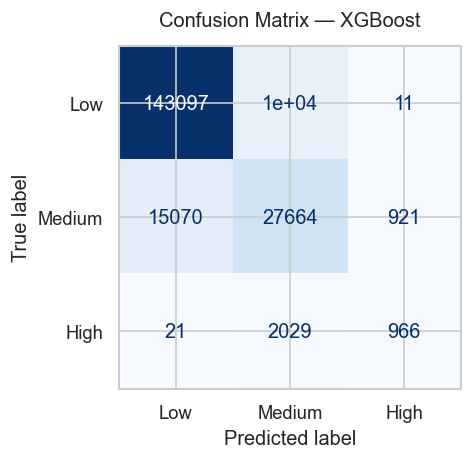

In [50]:
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                    eval_metric='mlogloss', verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

xgb_acc, xgb_f1 = evaluate_model('XGBoost', y_test, xgb_preds)
plot_confusion_matrix('XGBoost', y_test, xgb_preds)

In [51]:
xgb_cv = cross_val_score(xgb, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)

print("XGBoost — 5-Fold Cross-Validation")
print(f"  Fold scores: {xgb_cv.round(4)}")
print(f"  Mean F1:     {xgb_cv.mean():.4f}")
print(f"  Std:         {xgb_cv.std():.4f}")

results.append({'Model': 'XGBoost', 'Accuracy': xgb_acc,
                'F1 (test)': xgb_f1, 'CV F1 Mean': xgb_cv.mean(), 'CV F1 Std': xgb_cv.std()})

XGBoost — 5-Fold Cross-Validation
  Fold scores: [0.858  0.8613 0.8591 0.8585 0.8607]
  Mean F1:     0.8595
  Std:         0.0013


---
## 4. K-Nearest Neighbors (KNN)

### 4.1 Find the Best k
We iterate k from 1 to 20 using a 15k sample to find the optimal number of neighbours.

In [52]:
k_sample_X, k_sample_y = resample(X_train, y_train, n_samples=15000, random_state=42)

k_values  = range(1, 21)
k_f1s     = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_k.fit(k_sample_X, k_sample_y)
    preds = knn_k.predict(X_test)
    k_f1s.append(f1_score(y_test, preds, average='weighted'))
    print(f"k={k:2d}  F1: {k_f1s[-1]:.4f}")

k= 1  F1: 0.7979
k= 2  F1: 0.7984
k= 3  F1: 0.8128
k= 4  F1: 0.8145
k= 5  F1: 0.8244
k= 6  F1: 0.8221
k= 7  F1: 0.8300
k= 8  F1: 0.8274
k= 9  F1: 0.8336
k=10  F1: 0.8311
k=11  F1: 0.8362
k=12  F1: 0.8332
k=13  F1: 0.8375
k=14  F1: 0.8348
k=15  F1: 0.8385
k=16  F1: 0.8364
k=17  F1: 0.8393
k=18  F1: 0.8369
k=19  F1: 0.8398
k=20  F1: 0.8377


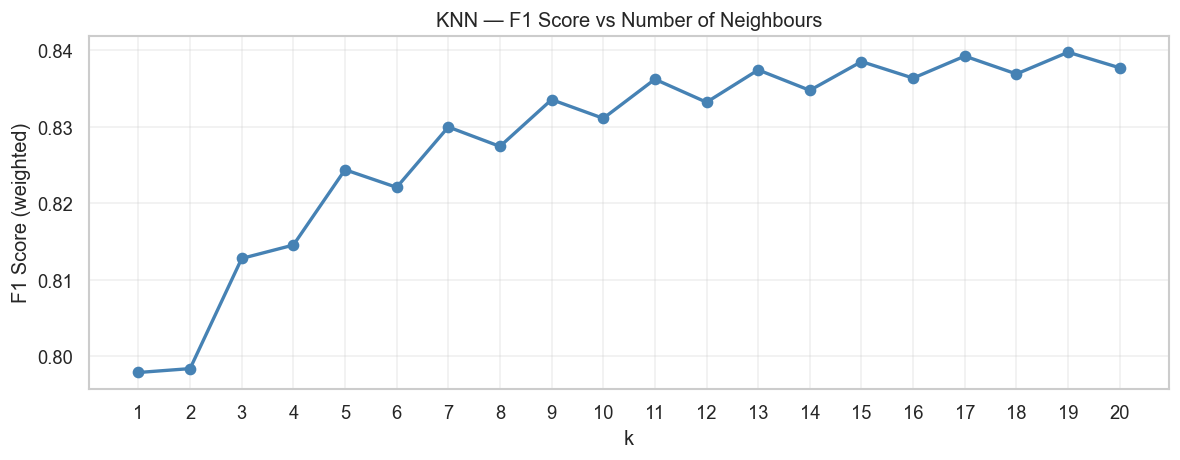

Best k: 19  |  F1: 0.8398


In [53]:
plt.figure(figsize=(10, 4))
plt.plot(list(k_values), k_f1s, marker='o', color='steelblue', linewidth=2)
plt.title('KNN — F1 Score vs Number of Neighbours')
plt.xlabel('k')
plt.ylabel('F1 Score (weighted)')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_values)[k_f1s.index(max(k_f1s))]
print(f"Best k: {best_k}  |  F1: {max(k_f1s):.4f}")

### 4.2 Train Final KNN with Best k


  KNN (k=19)
              precision    recall  f1-score   support

         Low       0.89      0.95      0.92    153329
      Medium       0.70      0.58      0.64     43655
        High       0.82      0.12      0.22      3016

    accuracy                           0.86    200000
   macro avg       0.80      0.55      0.59    200000
weighted avg       0.85      0.86      0.85    200000

Accuracy:        0.8551
F1 (weighted):   0.8455


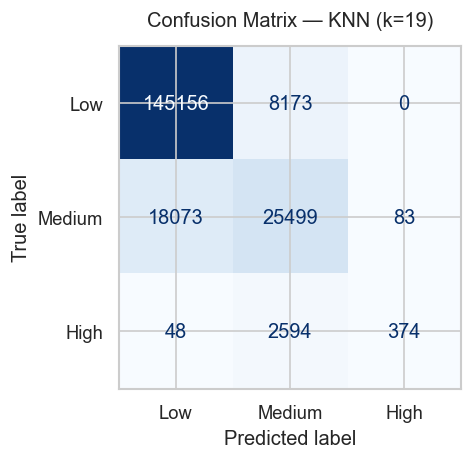

In [54]:
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

knn_acc, knn_f1 = evaluate_model(f'KNN (k={best_k})', y_test, knn_preds)
plot_confusion_matrix(f'KNN (k={best_k})', y_test, knn_preds)

In [55]:
knn_cv = cross_val_score(knn, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)

print(f"KNN (k={best_k}) — 5-Fold Cross-Validation")
print(f"  Fold scores: {knn_cv.round(4)}")
print(f"  Mean F1:     {knn_cv.mean():.4f}")
print(f"  Std:         {knn_cv.std():.4f}")

results.append({'Model': f'KNN (k={best_k})', 'Accuracy': knn_acc,
                'F1 (test)': knn_f1, 'CV F1 Mean': knn_cv.mean(), 'CV F1 Std': knn_cv.std()})

KNN (k=19) — 5-Fold Cross-Validation
  Fold scores: [0.8437 0.8485 0.8449 0.8509 0.8454]
  Mean F1:     0.8467
  Std:         0.0026


---
## 5. Support Vector Machine (SVM)
SVM with an RBF kernel. Trained on a 20k sample — SVM does not scale well to large datasets.


  SVM (RBF)
              precision    recall  f1-score   support

         Low       0.90      0.95      0.92    153329
      Medium       0.72      0.61      0.66     43655
        High       0.72      0.20      0.32      3016

    accuracy                           0.86    200000
   macro avg       0.78      0.59      0.63    200000
weighted avg       0.85      0.86      0.85    200000

Accuracy:        0.8625
F1 (weighted):   0.8546


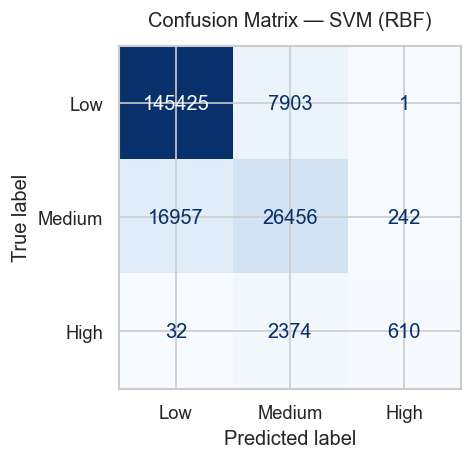

In [56]:
svm_X, svm_y = resample(X_train, y_train, n_samples=20000, random_state=42)

svm = SVC(kernel='rbf', random_state=42)
svm.fit(svm_X, svm_y)
svm_preds = svm.predict(X_test)

svm_acc, svm_f1 = evaluate_model('SVM (RBF)', y_test, svm_preds)
plot_confusion_matrix('SVM (RBF)', y_test, svm_preds)

In [57]:
svm_cv = cross_val_score(SVC(kernel='rbf', random_state=42),
                         svm_X, svm_y, cv=5, scoring='f1_weighted', n_jobs=-1)

print("SVM (RBF) — 5-Fold Cross-Validation (on 20k sample)")
print(f"  Fold scores: {svm_cv.round(4)}")
print(f"  Mean F1:     {svm_cv.mean():.4f}")
print(f"  Std:         {svm_cv.std():.4f}")

results.append({'Model': 'SVM (RBF)', 'Accuracy': svm_acc,
                'F1 (test)': svm_f1, 'CV F1 Mean': svm_cv.mean(), 'CV F1 Std': svm_cv.std()})

SVM (RBF) — 5-Fold Cross-Validation (on 20k sample)
  Fold scores: [0.8577 0.8603 0.8516 0.8583 0.8649]
  Mean F1:     0.8586
  Std:         0.0043


---
## Model Comparison

### Summary Table

In [58]:
df_results = pd.DataFrame(results).round(4)
df_results = df_results.sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
df_results.index += 1
print(df_results.to_string())

                 Model  Accuracy  F1 (test)  CV F1 Mean  CV F1 Std
1  Logistic Regression    0.8669     0.8624      0.8644     0.0011
2              XGBoost    0.8586     0.8548      0.8595     0.0013
3        Random Forest    0.8631     0.8561      0.8586     0.0021
4            SVM (RBF)    0.8625     0.8546      0.8586     0.0043
5           KNN (k=19)    0.8551     0.8455      0.8467     0.0026


### F1 Score Comparison Plot

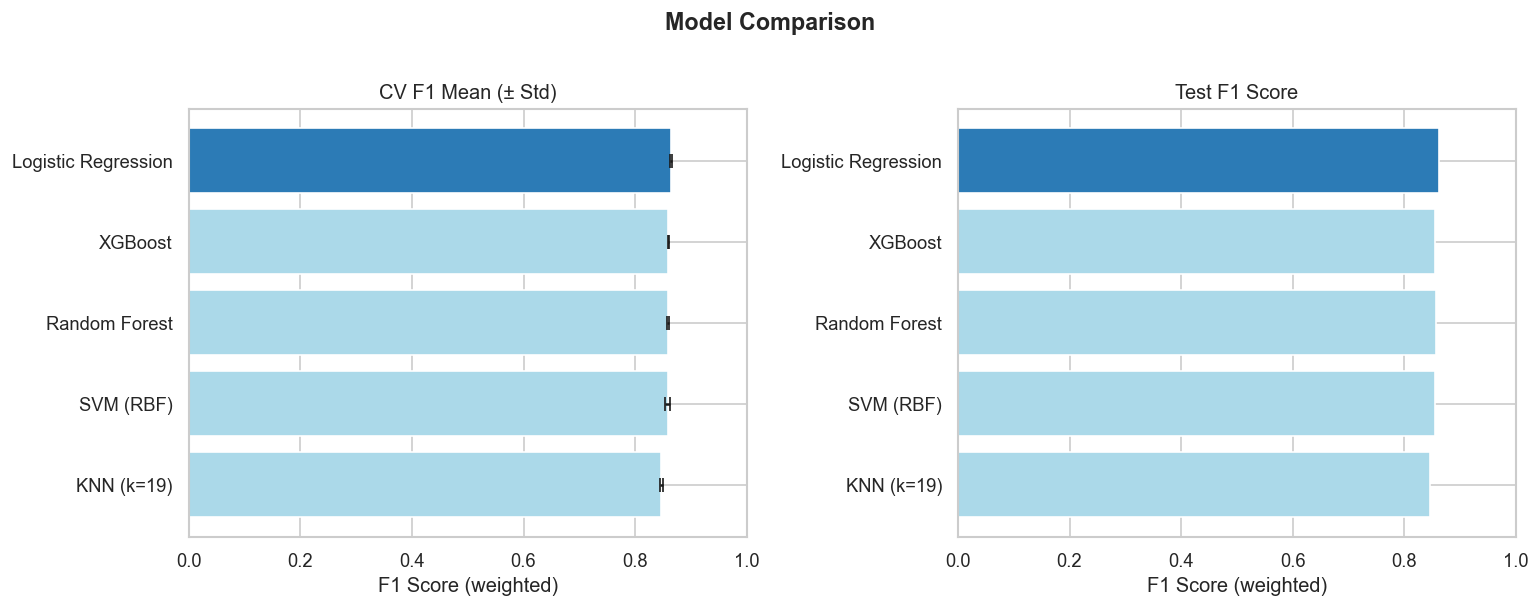

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models     = df_results['Model']
cv_means   = df_results['CV F1 Mean']
cv_stds    = df_results['CV F1 Std']
test_f1s   = df_results['F1 (test)']

# CV F1 with error bars
colors = ['#2c7bb6' if i == 0 else '#abd9e9' for i in range(len(models))]
axes[0].barh(models, cv_means, xerr=cv_stds, color=colors, edgecolor='white', capsize=4)
axes[0].set_title('CV F1 Mean (± Std)', fontsize=12)
axes[0].set_xlabel('F1 Score (weighted)')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1)

# Test F1
axes[1].barh(models, test_f1s, color=colors, edgecolor='white')
axes[1].set_title('Test F1 Score', fontsize=12)
axes[1].set_xlabel('F1 Score (weighted)')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Retrain Best Model on Full Dataset
The model with the highest CV F1 Mean is retrained on the complete training set for maximum performance.

Best model: Logistic Regression

  Logistic Regression (full data)
              precision    recall  f1-score   support

         Low       0.91      0.94      0.92    153329
      Medium       0.72      0.65      0.68     43655
        High       0.70      0.32      0.43      3016

    accuracy                           0.87    200000
   macro avg       0.77      0.63      0.68    200000
weighted avg       0.86      0.87      0.86    200000

Accuracy:        0.8671
F1 (weighted):   0.8624


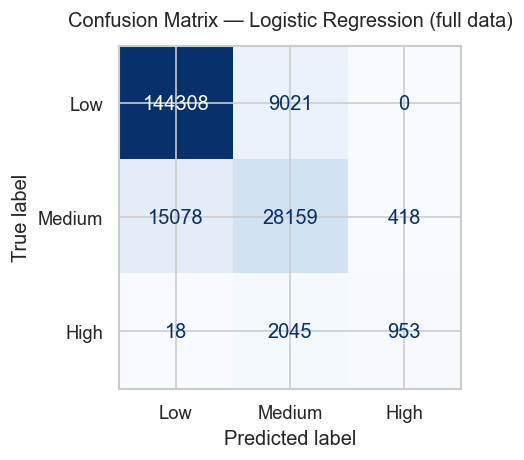

In [60]:
best_model_name = df_results.iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Map name to model object
model_map = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100,max_depth=12,min_samples_leaf=20,min_samples_split=40,random_state=42,n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='mlogloss', verbosity=0),
    f'KNN (k={best_k})':   KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
    'SVM (RBF)':           SVC(kernel='rbf', random_state=42),
}

best_model = model_map[best_model_name]
best_model.fit(X_train_full, y_train_full)

final_preds = best_model.predict(X_test)
final_acc, final_f1 = evaluate_model(f'{best_model_name} (full data)', y_test, final_preds)
plot_confusion_matrix(f'{best_model_name} (full data)', y_test, final_preds)

### Feature Importance
We can extract which features drove the predictions most.

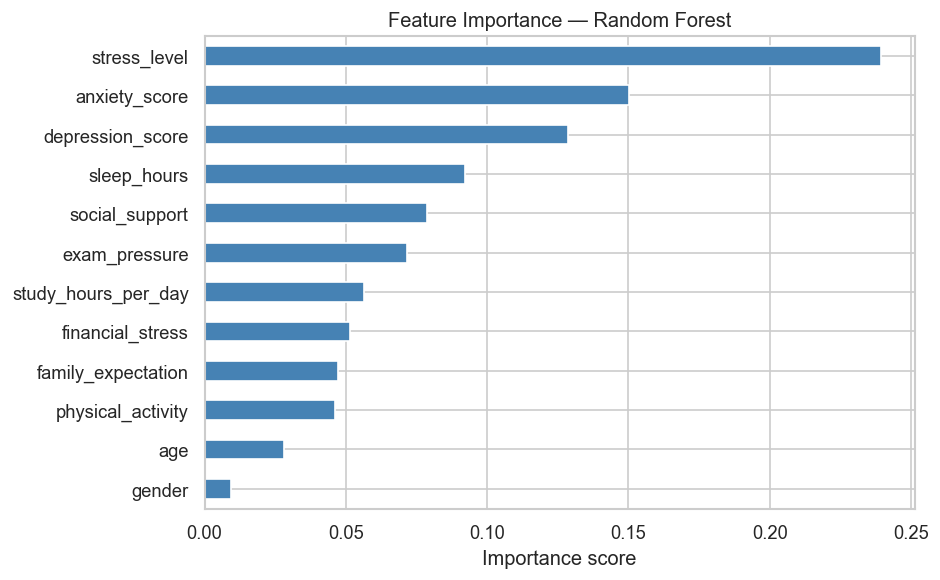


Top features:
stress_level           0.2393
anxiety_score          0.1502
depression_score       0.1285
sleep_hours            0.0923
social_support         0.0787
exam_pressure          0.0718
study_hours_per_day    0.0565
financial_stress       0.0515
family_expectation     0.0473
physical_activity      0.0463
age                    0.0282
gender                 0.0094
dtype: float64


In [21]:
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_names)
    importance = importance.sort_values(ascending=True)

    plt.figure(figsize=(8, 5))
    importance.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Feature Importance — {best_model_name}', fontsize=12)
    plt.xlabel('Importance score')
    plt.tight_layout()
    plt.show()

    print("\nTop features:")
    print(importance.sort_values(ascending=False).round(4))
else:
    print(f"{best_model_name} does not provide feature importances.")

---
## Save Best Model
The trained model is saved to `models/best_model.pkl` for use by the Flask backend.

In [61]:
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"Saved: best_model.pkl  ({best_model_name} trained on full dataset)")
print("Ready for backend/predict.py")

Saved: best_model.pkl  (Logistic Regression trained on full dataset)
Ready for backend/predict.py


---

## Conclusion — Best Model

After training and evaluating five classification models on the student mental health dataset,
**Logistic Regression** was selected as the final model based on cross-validation F1 score
and practical deployment considerations.

### Results summary

| Rank | Model               | Accuracy | F1 (test) | CV F1 Mean | CV F1 Std |
|------|---------------------|----------|-----------|------------|-----------|
| 1    | Logistic Regression | 0.8669   | 0.8624    | 0.8644     | 0.0011    |
| 2    | XGBoost             | 0.8586   | 0.8548    | 0.8595     | 0.0013    |
| 3    | Random Forest       | 0.8631   | 0.8561    | 0.8586     | 0.0021    |
| 4    | SVM (RBF)           | 0.8625   | 0.8546    | 0.8586     | 0.0043    |
| 5    | KNN (k=19)          | 0.8551   | 0.8455    | 0.8467     | 0.0026    |

### Why Logistic Regression?

**The performance gap between models is negligible.** All five models scored within roughly
2 percentage points of each other (0.8467 to 0.8644 CV F1). At this margin, the difference is
better explained by normal variation than by one model genuinely understanding the data
better than another. When scores are this close, model selection should weigh practical
factors alongside the raw metric.

**Random Forest was tuned for deployability, and the tradeoff wasn't worth it.** An
unconstrained Random Forest initially scored highest (0.8653 CV F1) but produced a 1.2GB
model file — impractical for a deployed web application. Constraining tree depth and leaf
size to make the file deployable (`max_depth=12`, `min_samples_leaf=20`,
`min_samples_split=40`) reduced the file size substantially, but also dropped its CV F1 to
0.8586 — now below Logistic Regression.

**Logistic Regression matches the performance at a fraction of the cost.** The trained model
is under 2KB, loads instantly, and achieved the highest CV F1 Mean (0.8644) with the lowest
standard deviation (0.0011) of any model tested — meaning it is also the most consistent
across folds.

**The data doesn't appear to need non-linear modelling.** Tree-based and kernel-based models
(Random Forest, XGBoost, SVM) all scored similarly to or below the linear model. This suggests
the relationships between survey features and burnout risk in this dataset are largely
additive — each factor (stress, sleep, anxiety, etc.) contributes independently rather than
interacting in complex, conditional ways. If strong feature interactions existed, the
non-linear models would be expected to clearly outperform Logistic Regression, which did not
happen here.

### Why not the others?

- **Random Forest** — competitive performance, but the engineering cost of making it
  deployment-sized (over 500x larger than Logistic Regression even after constraint tuning)
  wasn't justified given the near-identical score. It remains useful for the EDA feature
  importance analysis earlier in this project.
- **XGBoost** — close second (0.8595 CV F1), but did not outperform Logistic Regression and
  carries more deployment complexity (additional dependency, larger model file).
- **SVM (RBF)** — reasonable score (0.8586) but had to be trained on a reduced 20k sample due
  to computational cost, making its evaluation less reliable than the other models.
- **KNN (k=19)** — weakest performer at 0.8467 CV F1, sensitive to the curse of
  dimensionality and does not scale well to large datasets.

### Final model

The Logistic Regression model was retrained on the full training dataset and saved to
`models/best_model.pkl` (under 2KB). This is the model loaded by the Flask backend to serve
predictions in the web application. SHAP explainability (using `LinearExplainer`) and the
AI recommendation agent both operate on this model in `backend/agent.py`.